In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import emoji

In [2]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comments.shape}")
print("\nMissing values per column (posts):")
print(posts.isna().sum())
print("\nMissing values per column (comments):")
print(comments.isna().sum())

print(f"\nDuplicate posts: {posts.duplicated(subset='msg_id').sum()}")
print(f"Duplicate comments: {comments.duplicated(subset='comment_id').sum()}")

Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Missing values per column (posts):
msg_id                0
date_utc              0
text                 39
views                 0
forwards              0
replies               0
has_media             0
media_type           28
sender_id             0
reply_to_msg_id    1943
num_comments          0
dtype: int64

Missing values per column (comments):
post_id           0
comment_id        0
date_utc          0
text           6840
sender_id     32160
dtype: int64

Duplicate posts: 0
Duplicate comments: 0


In [3]:
# ================= FILL MISSING VALUES =================
posts['views'] = posts['views'].fillna(0)
posts['forwards'] = posts['forwards'].fillna(0)
posts['replies'] = posts['replies'].fillna(0)
posts['media_type'] = posts['media_type'].fillna('Unknown')
posts['text'] = posts['text'].fillna('<media_only>')
posts['reply_to_msg_id'] = posts['reply_to_msg_id'].fillna('None')

comments['text'] = comments['text'].fillna('<deleted>')
comments['sender_id'] = comments['sender_id'].fillna('Unknown')


In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Remove URLs (links)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Remove mentions and hashtags (optional - keep if needed for analysis)
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    # text = re.sub(r'#\w+', '', text)  # uncomment to remove hashtags
    
    # 3. Remove emojis OR convert them to text
    # Option A: Remove emojis
    text = emoji.replace_emoji(text, replace='')
    # Option B: Convert emojis to text (useful for sentiment)
    # text = emoji.demojize(text, delimiters=(":", ":"))
    
    # 4. Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\u1200-\u137F\s]', '', text)  # keeps Amharic and English
    
    # 5. Convert to lowercase (if English-heavy, but Amharic doesn't have case)
    text = text.lower()
    
    # 6. Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning
posts['cleaned_text'] = posts['text'].apply(clean_text)
comments['cleaned_text'] = comments['text'].apply(clean_text)

In [5]:
#========================= feature engineering =========================
# For posts
posts['text_length'] = posts['cleaned_text'].str.len()
posts['word_count'] = posts['cleaned_text'].str.split().str.len()
posts['has_question'] = posts['cleaned_text'].str.contains('\?').astype(int)

# Feature engineering for comments
comments['text_length'] = comments['cleaned_text'].str.len()
comments['word_count'] = comments['cleaned_text'].str.split().str.len()

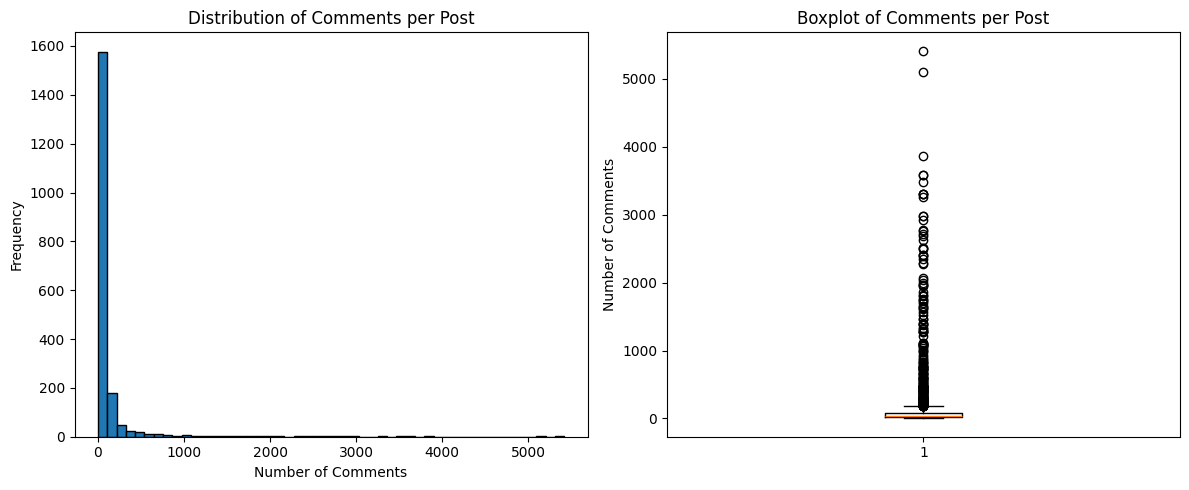

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(posts['num_comments'], bins=50, edgecolor='black')
plt.title('Distribution of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(posts['num_comments'])
plt.title('Boxplot of Comments per Post')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()

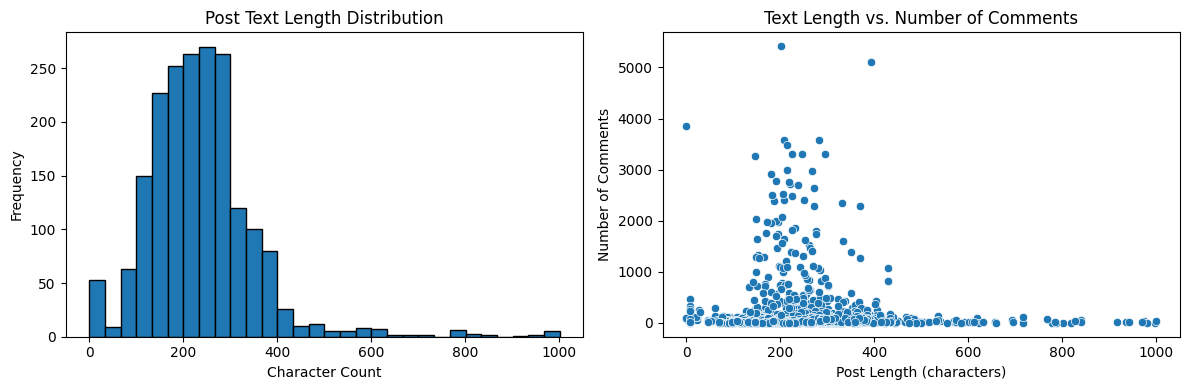

              text_length  num_comments
text_length      1.000000     -0.010929
num_comments    -0.010929      1.000000


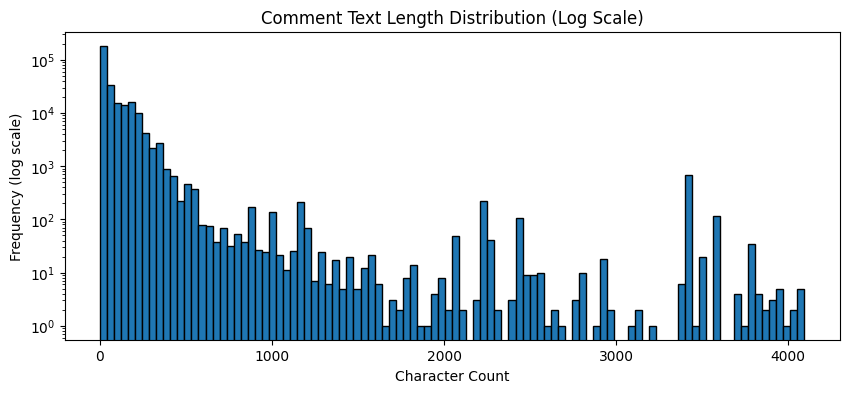

In [6]:
# Post text length distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(posts['text_length'], bins=30, edgecolor='black')
plt.title('Post Text Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.scatterplot(x=posts['text_length'], y=posts['num_comments'])
plt.title('Text Length vs. Number of Comments')
plt.xlabel('Post Length (characters)')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()

# Correlation
print(posts[['text_length', 'num_comments']].corr())

#======================= Comment level analysis ========================
plt.figure(figsize=(10, 4))
plt.hist(comments['text_length'], bins=100, edgecolor='black', log=True)
plt.title('Comment Text Length Distribution (Log Scale)')
plt.xlabel('Character Count')
plt.ylabel('Frequency (log scale)')
plt.show()

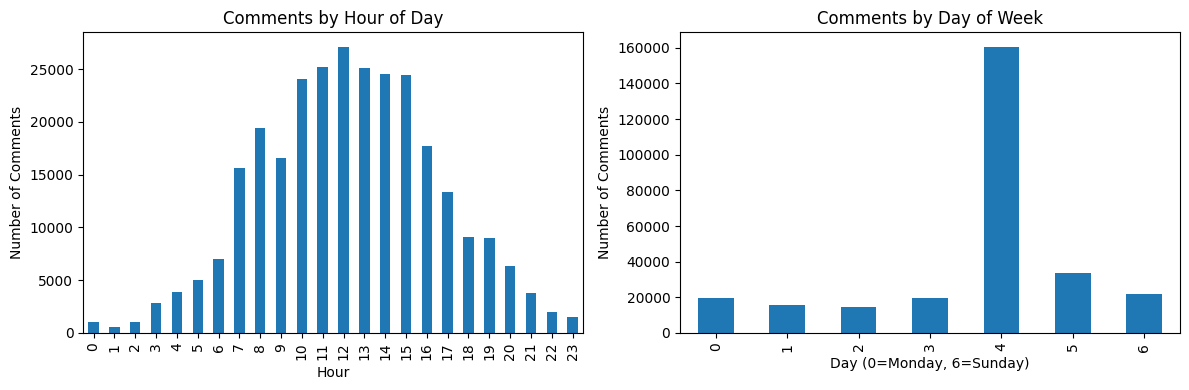

In [7]:
# Convert date_utc to datetime if not already
comments['date_utc'] = pd.to_datetime(comments['date_utc'])
posts['date_utc'] = pd.to_datetime(posts['date_utc'])

# Comments by hour of day
comments['hour'] = comments['date_utc'].dt.hour
comments['day_of_week'] = comments['date_utc'].dt.dayofweek

# Plot comment activity by hour
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
comments['hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Comments by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Comments')

plt.subplot(1, 2, 2)
comments['day_of_week'].value_counts().sort_index().plot(kind='bar')
plt.title('Comments by Day of Week')
plt.xlabel('Day (0=Monday, 6=Sunday)')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

In [8]:
# Using simple approach (you can use pre-trained models for Amharic)
from textblob import TextBlob  # works for English

def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply to English comments only (or use Amharic sentiment model)
comments[['polarity', 'subjectivity']] = comments['cleaned_text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Sentiment distribution per post
post_sentiment = comments.groupby('post_id')['polarity'].mean()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=1000)
post_vectors = vectorizer.fit_transform(posts['cleaned_text'])
comment_vectors = vectorizer.transform(comments['cleaned_text'])

# Calculate similarity between each comment and its parent post
# (you'd need to match comment to post_id)

# Topic modeling on posts
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
post_tfidf = tfidf.fit_transform(posts['cleaned_text'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(post_tfidf)

# Display topics
def display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

display_topics(lda, tfidf.get_feature_names_out(), 10)

Topic 0:
እና ኢትዮጵያ ጋር ነው ደቂቃ አገልግሎት ሙዚቃ የዲጂታል ላይ ቅመም
Topic 1:
safaricomethiopia ወደፊት እንኳን እና ኔትዎርክ furtheraheadtogether በአብሮነት አሁንም wedefit መልካም
Topic 2:
ከሳፋሪኮም ወደ በሽ ብለን ወይም wedefit በመላክ እናዉርድ ቁጥራችን ጋር
Topic 3:
ልዩ ጥቅል mediaonly ዳታ እንግዛ safaricomethiopia ያልተገደበ ጊባ የዳታ ሳፋሪኮም
Topic 4:
በmpesa mpesa እናውርድ መተግበሪያን ወይም የmpesa የበሽ የቴሌግራም ላይ እዚህ


# 📊 Advanced EDA Steps
## 1. Text Content Analysis
A. Most Common Words (Word Clouds)

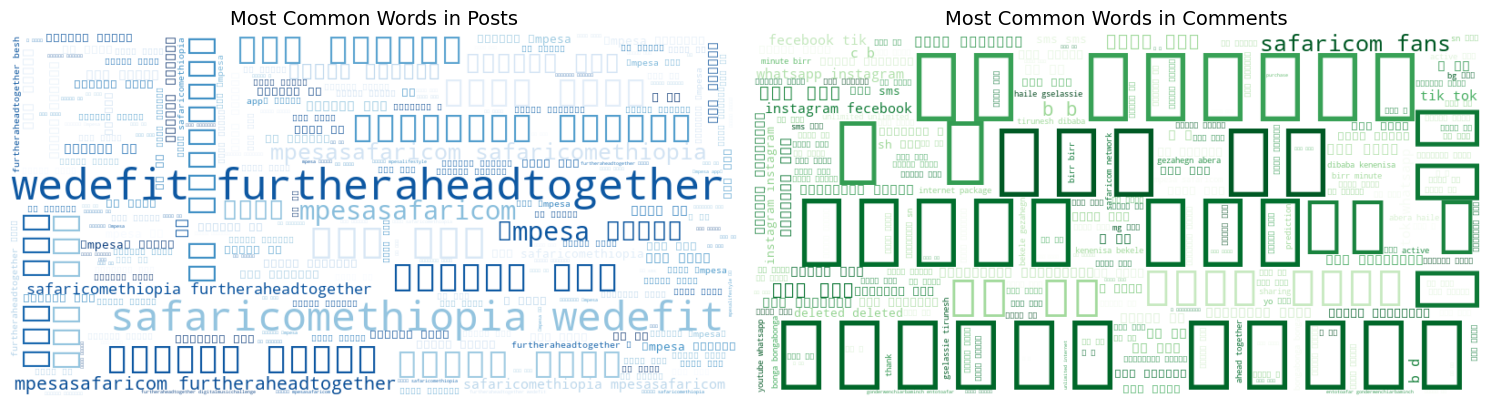

Top 20 words in comments:
  ደቂቃ: 135023
  ኔትወርክ: 106328
  በተመሳሳይ: 104199
  for: 46117
  safaricom: 44179
  ሰላም፣: 32884
  መልካም: 32784
  ክሬዲት: 31186
  fans: 30018
  ላይክ: 24488
  the: 23075
  ዕድል: 22032
  ምንም: 21053
  ጥቅል: 18142
  mpesa: 16557
  your: 15517
  instagram: 15073
  you: 14148
  ካርድ: 13982
  birr: 13304


In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re

# Combine all post texts
all_post_text = ' '.join(posts['cleaned_text'].dropna())
all_comment_text = ' '.join(comments['cleaned_text'].dropna())

# Create word clouds
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
wordcloud_posts = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Blues', font_path=None).generate(all_post_text)
plt.imshow(wordcloud_posts, interpolation='bilinear')
plt.title('Most Common Words in Posts', fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_comments = WordCloud(width=800, height=400, background_color='white',
                               colormap='Greens', font_path=None).generate(all_comment_text)
plt.imshow(wordcloud_comments, interpolation='bilinear')
plt.title('Most Common Words in Comments', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

# Top 20 words in comments (excluding stop words)
stop_words = {'ለ', 'በ', 'እና', 'የ', 'እንደ', 'ላይ', 'ታይ', 'ነው', 'ማድረግ', 'ቁም'}
comment_words = all_comment_text.split()
comment_word_freq = Counter([w for w in comment_words if w not in stop_words and len(w) > 2])
print("Top 20 words in comments:")
for word, count in comment_word_freq.most_common(20):
    print(f"  {word}: {count}")

B. N-gram Analysis (Common Phrases)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams in comments
vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=20)
comment_bigrams = vectorizer.fit_transform(comments['cleaned_text'].dropna())
bigram_counts = comment_bigrams.toarray().sum(axis=0)
bigram_names = vectorizer.get_feature_names_out()

print("Top 10 bigrams/trigrams in comments:")
for name, count in sorted(zip(bigram_names, bigram_counts), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {name}: {count}")

Top 10 bigrams/trigrams in comments:
  በተመሳሳይ ኔትወርክ: 103906
  ጥሪ በተመሳሳይ: 100186
  ደቂቃ ጥሪ: 100136
  ደቂቃ ጥሪ በተመሳሳይ: 100129
  ጥሪ በተመሳሳይ ኔትወርክ: 99990
  ኔትወርክ ደቂቃ: 98731
  ኔትወርክ ደቂቃ ጥሪ: 97344
  በተመሳሳይ ኔትወርክ ደቂቃ: 97308
  ጊዜ ጊዜ: 85050
  ጊዜ ጊዜ ጊዜ: 84666


## 2. Engagement Pattern Analysis
A. Does Post Length Affect Engagement?

Engagement by post length:
                       mean  median  count
length_category                           
Very Short        99.400000    64.5     50
Short             72.485294    29.5    340
Medium           179.313096    41.0   1153
Long             114.821159    47.0    397


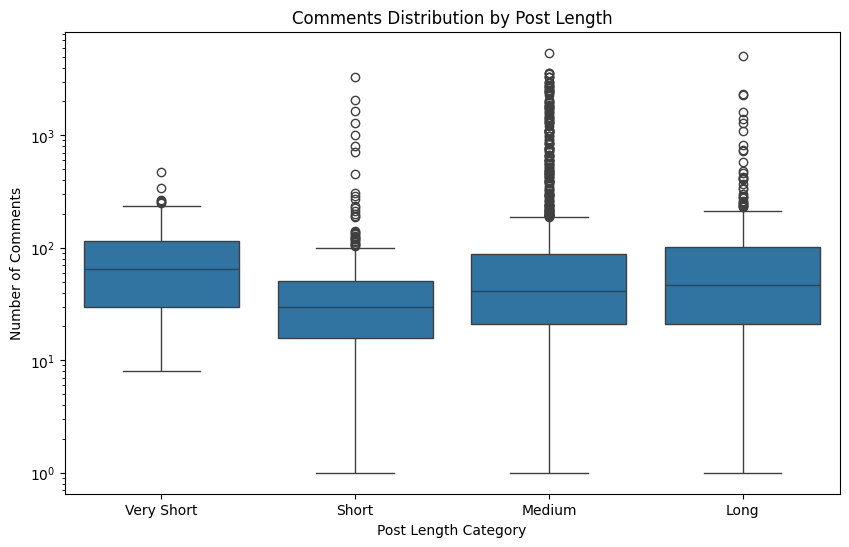

In [12]:
# Create length categories
posts['length_category'] = pd.cut(posts['text_length'], 
                                   bins=[0, 50, 150, 300, 1000], 
                                   labels=['Very Short', 'Short', 'Medium', 'Long'])

# Average comments by length category
length_engagement = posts.groupby('length_category', observed=True)['num_comments'].agg(['mean', 'median', 'count'])
print("Engagement by post length:")
print(length_engagement)

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='length_category', y='num_comments', data=posts, order=['Very Short', 'Short', 'Medium', 'Long'])
plt.title('Comments Distribution by Post Length')
plt.xlabel('Post Length Category')
plt.ylabel('Number of Comments')
plt.yscale('log')  # Log scale due to outliers
plt.show()

B. Do Questions Generate More Comments?

In [ ]:
# Compare posts with and without questions
question_engagement = posts.groupby('has_question')['num_comments'].agg(['mean', 'median', 'count'])
print("Engagement: Questions vs No Questions")
print(question_engagement)

# Statistical test
from scipy import stats
question_posts = posts[posts['has_question'] == 1]['num_comments']
no_question_posts = posts[posts['has_question'] == 0]['num_comments']
t_stat, p_value = stats.mannwhitneyu(question_posts, no_question_posts)
print(f"\nMann-Whitney U test p-value: {p_value:.4f}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")